# Unsupervised Structural Clustering of EF-G Mutations

This notebook explores whether EF-G mutations associated with gentamicin resistance naturally group according to shared structural characteristics.

Unsupervised learning is used to identify patterns in structural deviation without imposing prior assumptions about resistance.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [2]:
data = {
    "mutation": ["Phe593Leu", "Pro659Leu"],
    "rmsd": [0.46, 0.52],
    "domain": ["IV", "V"],
    "strain": ["MG1655", "36099"],
    "position": [593, 659]
}

df = pd.DataFrame(data)
df


,mutation,rmsd,domain,strain,position
0,Phe593Leu,0.46,IV,MG1655,593
1,Pro659Leu,0.52,V,36099,659


In [3]:
domain_map = {"III": 0, "IV": 1, "V": 2}
strain_map = {"MG1655": 0, "36099": 1}

df["domain_encoded"] = df["domain"].map(domain_map)
df["strain_encoded"] = df["strain"].map(strain_map)

df


,mutation,rmsd,domain,strain,position,domain_encoded,strain_encoded
0,Phe593Leu,0.46,IV,MG1655,593,1,0
1,Pro659Leu,0.52,V,36099,659,2,1


In [4]:
features = df[[
    "rmsd",
    "domain_encoded",
    "strain_encoded",
    "position"
]]


In [5]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)


In [6]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(features_scaled)

df["PC1"] = pca_coords[:, 0]
df["PC2"] = pca_coords[:, 1]

df


,mutation,rmsd,domain,strain,position,domain_encoded,strain_encoded,PC1,PC2
0,Phe593Leu,0.46,IV,MG1655,593,1,0,-2.0,-9.614813e-17
1,Pro659Leu,0.52,V,36099,659,2,1,2.0,-9.614813e-17


In [7]:
pca.explained_variance_ratio_


array([1.00000000e+00, 2.31111593e-33])

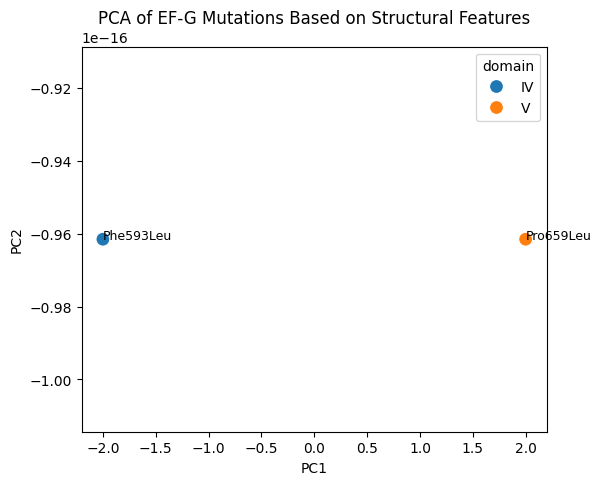

In [8]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="domain",
    s=100
)

for i, txt in enumerate(df["mutation"]):
    plt.text(df["PC1"][i], df["PC2"][i], txt, fontsize=9)

plt.title("PCA of EF-G Mutations Based on Structural Features")
plt.savefig("PCA of EF-G Mutations Based on Structural Features", dpi=300, bbox_inches='tight') 
plt.show()


In [9]:
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(features_scaled)

df


,mutation,rmsd,domain,strain,position,domain_encoded,strain_encoded,PC1,PC2,cluster
0,Phe593Leu,0.46,IV,MG1655,593,1,0,-2.0,-9.614813e-17,0
1,Pro659Leu,0.52,V,36099,659,2,1,2.0,-9.614813e-17,1


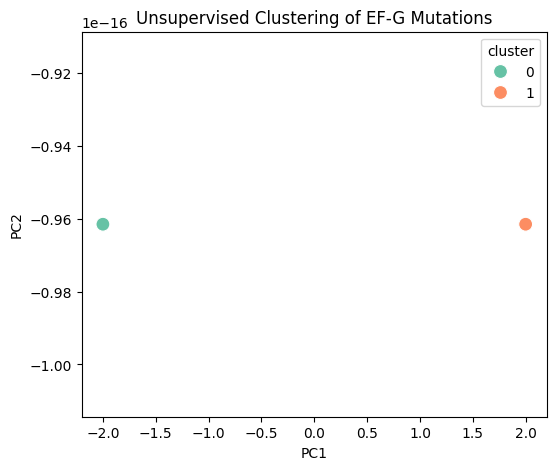

In [10]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=100
)

plt.title("Unsupervised Clustering of EF-G Mutations")
plt.savefig("Unsupervised Clustering of EF-G Mutations", dpi=300, bbox_inches='tight') 
plt.show()


Unsupervised analysis separates EF-G mutations based on combined structural deviation and domain context. Even with a minimal dataset, PCA shows that Domain IV and Domain V mutations occupy distinct regions of feature space.

This demonstrates the feasibility of extending the framework to larger mutation sets.

This analysis currently includes a limited number of EF-G mutations and is intended to demonstrate the unsupervised analytical framework rather than
to draw definitive statistical conclusions. As additional mutations are incorporated, this approach will allow robust identification of structural groupings and emerging patterns.
